In [ ]:
import os
import numpy as np
import pandas as pd
from glob import glob
from collections import Counter

# ===== 參數設定 =====
DATASET_DIR = "../datasets/pathological_gait_datasets-master/Pathological_Gaits"
OUTPUT_DIR = "../datasets/processed_data"
OUTPUT_FILE = os.path.join(OUTPUT_DIR, "patho50_data.npz")

SELECTED_JOINTS = [18, 17, 16, 0, 12, 13, 14]
FRAME_THRESHOLD = 60
USE_FRAMES = 50
SKIP_FRAMES = 10

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ===== 讀取 CSV -> (frames, 25, 3) =====
def load_skeleton_csv(file_path):
    df = pd.read_csv(file_path, header=None, sep="\t", engine="python")
    frames = []
    for _, row in df.iterrows():
        row = row.astype(float).values
        row = row[1:]  # 跳過時間戳
        coords = []
        for j in range(25):
            idx = j * 4 + 1
            x, y, z = row[idx:idx+3]
            coords.append([x, y, z])
        frames.append(coords)
    return np.array(frames)

# ===== spine base (joint 0) 平移正規化 =====
def normalize_skeleton(skel):
    spine = skel[:, 0:1, :]
    return skel - spine

# ===== 主處理流程 =====
def preprocess_dataset():
    all_data, all_labels, all_subjects = [], [], []

    # 只取 gait type 當分類
    gait_types = sorted(set(os.path.basename(p).split('_')[1].rstrip('0123456789') 
                            for p in glob(f"{DATASET_DIR}/*")))
    label_map = {g: i for i, g in enumerate(gait_types)}

    for clip_dir in glob(f"{DATASET_DIR}/*"):
        parts = os.path.basename(clip_dir).split('_')
        subject_id = parts[0]  # 例如 human01
        gait_type = parts[1].rstrip('0123456789')

        label = label_map[gait_type]

        for csv_file in glob(f"{clip_dir}/*.csv"):
            skel = load_skeleton_csv(csv_file)
            if len(skel) < FRAME_THRESHOLD:
                continue

            # 前 10 幀丟掉，取後面 50 幀
            skel = skel[SKIP_FRAMES:SKIP_FRAMES + USE_FRAMES]

            # 正規化 & 取下半身 joints
            skel = normalize_skeleton(skel)
            skel = skel[:, SELECTED_JOINTS, :]

            # 轉成 (3, T, V, 1)
            seq = np.transpose(skel, (2, 0, 1))
            seq = seq[..., np.newaxis]

            all_data.append(seq)
            all_labels.append(label)
            all_subjects.append(subject_id)

    all_data = np.array(all_data)
    all_labels = np.array(all_labels)
    all_subjects = np.array(all_subjects)

    # 儲存
    np.savez(OUTPUT_FILE, data=all_data, labels=all_labels, subjects=all_subjects)

    # 印出資料統計
    print(f"✅ 輸出檔案：{OUTPUT_FILE}")
    print(f"資料 shape: {all_data.shape}")
    print(f"標籤 shape: {all_labels.shape}")
    print(f"受試者 shape: {all_subjects.shape}")
    print(f"總 clips 數: {len(all_labels)}")
    print(f"各類別數量: {Counter(all_labels)}")
    print(f"受試者數量: {len(set(all_subjects))} → {set(all_subjects)}")
    print(f"標籤對應：{label_map}")

if __name__ == "__main__":
    preprocess_dataset()


In [ ]:
import os
import numpy as np
import pandas as pd
from glob import glob
from collections import Counter

# ===== 參數設定 =====
DATASET_DIR = "../datasets/pathological_gait_datasets-master/Pathological_Gaits"
OUTPUT_DIR = "../datasets/processed_data"
OUTPUT_FILE = os.path.join(OUTPUT_DIR, "patho50_data_noNorm.npz")  # 改檔名避免覆蓋

SELECTED_JOINTS = [18, 17, 16, 0, 12, 13, 14]
FRAME_THRESHOLD = 60
USE_FRAMES = 50
SKIP_FRAMES = 10

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ===== 讀取 CSV -> (frames, 25, 3) =====
def load_skeleton_csv(file_path):
    df = pd.read_csv(file_path, header=None, sep="\t", engine="python")
    frames = []
    for _, row in df.iterrows():
        row = row.astype(float).values
        row = row[1:]  # 跳過時間戳
        coords = []
        for j in range(25):
            idx = j * 4 + 1
            x, y, z = row[idx:idx+3]
            coords.append([x, y, z])
        frames.append(coords)
    return np.array(frames)  # (frames, 25, 3)

# ===== 主處理流程（無平移正規化） =====
def preprocess_dataset():
    all_data, all_labels, all_subjects = [], [], []

    # 只取 gait type 當分類
    gait_types = sorted(set(os.path.basename(p).split('_')[1].rstrip('0123456789') 
                            for p in glob(f"{DATASET_DIR}/*")))
    label_map = {g: i for i, g in enumerate(gait_types)}

    for clip_dir in glob(f"{DATASET_DIR}/*"):
        parts = os.path.basename(clip_dir).split('_')
        subject_id = parts[0]  # 例如 human01
        gait_type = parts[1].rstrip('0123456789')

        label = label_map[gait_type]

        for csv_file in glob(f"{clip_dir}/*.csv"):
            skel = load_skeleton_csv(csv_file)
            if len(skel) < FRAME_THRESHOLD:
                continue

            # 前 10 幀丟掉，取後面 50 幀
            skel = skel[SKIP_FRAMES:SKIP_FRAMES + USE_FRAMES]

            # 直接取下半身 joints（❌ 不做平移正規化）
            skel = skel[:, SELECTED_JOINTS, :]

            # 轉成 (3, T, V, 1)
            seq = np.transpose(skel, (2, 0, 1))
            seq = seq[..., np.newaxis]

            all_data.append(seq)
            all_labels.append(label)
            all_subjects.append(subject_id)

    all_data = np.array(all_data)
    all_labels = np.array(all_labels)
    all_subjects = np.array(all_subjects)

    # 儲存
    np.savez(OUTPUT_FILE, data=all_data, labels=all_labels, subjects=all_subjects)

    # 印出資料統計
    print(f"✅ 輸出檔案：{OUTPUT_FILE}")
    print(f"資料 shape: {all_data.shape}")
    print(f"標籤 shape: {all_labels.shape}")
    print(f"受試者 shape: {all_subjects.shape}")
    print(f"總 clips 數: {len(all_labels)}")
    print(f"各類別數量: {Counter(all_labels)}")
    print(f"受試者數量: {len(set(all_subjects))} → {set(all_subjects)}")
    print(f"標籤對應：{label_map}")

if __name__ == "__main__":
    preprocess_dataset()


In [ ]:
import numpy as np

# 讀取資料
npz = np.load("../datasets/processed_data/patho50_data_noNorm.npz")
data = npz["data"]
labels = npz["labels"]
subjects = npz["subjects"]

unique_subjects = np.unique(subjects)

for test_sub in unique_subjects:
    # 測試集 index
    test_idx = (subjects == test_sub)
    # 訓練集 index
    train_idx = ~test_idx

    X_train, y_train = data[train_idx], labels[train_idx]
    X_test, y_test = data[test_idx], labels[test_idx]

    print(f"Subject {test_sub} → train: {X_train.shape[0]} | test: {X_test.shape[0]}")

    # 這裡就可以丟進你的 MSTGCN / AGS-GCN 模型去訓練 & 測試


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from net.mt_gsgcn_model import Model  # 你的 AGS-GCN 模型

# === 載入 Patho50 資料 ===
npz = np.load("../datasets/processed_data/patho50_data_noNorm.npz")
data = npz["data"]      # (N, 3, 50, 7, 1)
labels = npz["labels"]  # (N,)
subjects = npz["subjects"]  # (N,)

unique_subjects = np.unique(subjects)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === 建立模型 ===
def build_ags_gcn():
    return Model(in_channels=3, num_class=6,
                 graph_args={'layout': 'custom_7joints_spine', 'strategy': 'spatial'},
                 edge_importance_weighting=True)

# === 訓練模型（每100回合顯示一次狀態） ===
def train_model(model, train_loader, total_epochs=300):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.1, weight_decay=0.001)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.1)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(total_epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            out = model(X_batch.to(device))
            loss = criterion(out, y_batch.to(device))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            preds = out.argmax(dim=1)
            correct += (preds.cpu() == y_batch).sum().item()
            total += y_batch.size(0)

        scheduler.step()

        # 每 100 回合顯示一次
        if (epoch + 1) % 100 == 0:
            avg_loss = total_loss / total if total > 0 else 0
            acc = correct / total * 100 if total > 0 else 0
            print(f"[Epoch {epoch+1}] Loss: {avg_loss:.4f} | Acc: {acc:.2f}%")

# === 測試模型 ===
def evaluate_model(model, test_loader):
    model.eval()
    preds_all, trues_all = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds = model(X_batch.to(device)).argmax(dim=1)
            preds_all.extend(preds.cpu().numpy())
            trues_all.extend(y_batch.numpy())

    acc = np.mean(np.array(preds_all) == np.array(trues_all)) * 100
    f1 = f1_score(trues_all, preds_all, average='macro')
    cm = confusion_matrix(trues_all, preds_all)
    disp = ConfusionMatrixDisplay(cm, display_labels=['antalgic','lurch','normal','steppage','stiff','trendelenburg'])
    disp.plot(cmap='Blues')
    plt.show()
    return acc, f1

# === 只跑第一位受試者 ===
test_sub = unique_subjects[1]
print(f"\n=== 測試 Subject: {test_sub} ===")
test_idx = (subjects == test_sub)
train_idx = ~test_idx

X_train = torch.tensor(data[train_idx], dtype=torch.float32)  # 不 squeeze
y_train = torch.tensor(labels[train_idx], dtype=torch.long)
X_test = torch.tensor(data[test_idx], dtype=torch.float32)    # 不 squeeze
y_test = torch.tensor(labels[test_idx], dtype=torch.long)


train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)

model = build_ags_gcn()
train_model(model, train_loader, total_epochs=500)
acc, f1 = evaluate_model(model, test_loader)
print(f"測試集準確率: {acc:.2f}% | 測試集 F1-score: {f1:.4f}")



=== 測試 Subject: human1 ===
[Epoch   5] LR: 1.00e-02 | Train Loss: 0.2581 | Train Acc: 91.60%
[Epoch  10] LR: 1.00e-02 | Train Loss: 0.1323 | Train Acc: 96.12%
[Epoch  15] LR: 1.00e-02 | Train Loss: 0.1423 | Train Acc: 95.46%
[Epoch  20] LR: 1.00e-02 | Train Loss: 0.1023 | Train Acc: 96.86%
[Epoch  25] LR: 1.00e-02 | Train Loss: 0.0802 | Train Acc: 97.73%
[Epoch  30] LR: 1.00e-03 | Train Loss: 0.1015 | Train Acc: 96.99%
[Epoch  35] LR: 1.00e-03 | Train Loss: 0.0328 | Train Acc: 99.25%
[Epoch  40] LR: 1.00e-03 | Train Loss: 0.0286 | Train Acc: 99.35%
[Epoch  45] LR: 1.00e-03 | Train Loss: 0.0277 | Train Acc: 99.46%
[Epoch  50] LR: 1.00e-03 | Train Loss: 0.0227 | Train Acc: 99.52%
[Epoch  55] LR: 1.00e-03 | Train Loss: 0.0230 | Train Acc: 99.47%
[Epoch  60] LR: 1.00e-04 | Train Loss: 0.0214 | Train Acc: 99.63%
[Epoch  65] LR: 1.00e-04 | Train Loss: 0.0175 | Train Acc: 99.75%
[Epoch  70] LR: 1.00e-04 | Train Loss: 0.0162 | Train Acc: 99.72%
[Epoch  75] LR: 1.00e-04 | Train Loss: 0.0180 | 

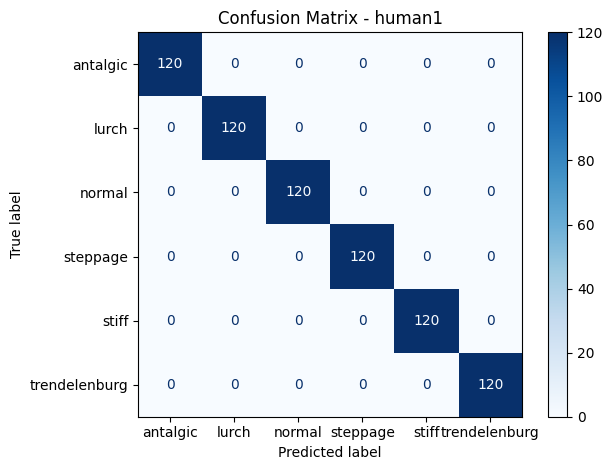

測試集準確率: 100.00% | 測試集 F1-score: 1.0000

=== 測試 Subject: human10 ===
[Epoch   5] LR: 1.00e-02 | Train Loss: 0.2011 | Train Acc: 93.69%
[Epoch  10] LR: 1.00e-02 | Train Loss: 0.1418 | Train Acc: 95.71%
[Epoch  15] LR: 1.00e-02 | Train Loss: 0.1221 | Train Acc: 96.36%
[Epoch  20] LR: 1.00e-02 | Train Loss: 0.1116 | Train Acc: 96.80%
[Epoch  25] LR: 1.00e-02 | Train Loss: 0.1362 | Train Acc: 95.53%
[Epoch  30] LR: 1.00e-03 | Train Loss: 0.1002 | Train Acc: 97.16%
[Epoch  35] LR: 1.00e-03 | Train Loss: 0.0415 | Train Acc: 99.13%
[Epoch  40] LR: 1.00e-03 | Train Loss: 0.0396 | Train Acc: 99.05%
[Epoch  45] LR: 1.00e-03 | Train Loss: 0.0385 | Train Acc: 99.19%
[Epoch  50] LR: 1.00e-03 | Train Loss: 0.0300 | Train Acc: 99.38%
[Epoch  55] LR: 1.00e-03 | Train Loss: 0.0353 | Train Acc: 99.25%
[Epoch  60] LR: 1.00e-04 | Train Loss: 0.0286 | Train Acc: 99.44%
[Epoch  65] LR: 1.00e-04 | Train Loss: 0.0208 | Train Acc: 99.67%
[Epoch  70] LR: 1.00e-04 | Train Loss: 0.0190 | Train Acc: 99.75%
[Epoch  

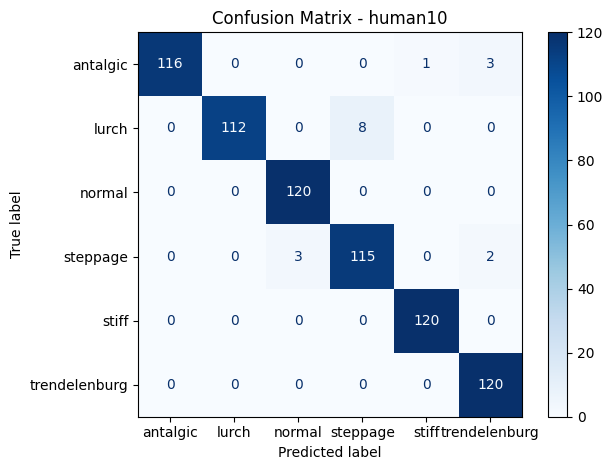

測試集準確率: 97.64% | 測試集 F1-score: 0.9764

=== 測試 Subject: human2 ===
[Epoch   5] LR: 1.00e-02 | Train Loss: 0.1861 | Train Acc: 94.06%
[Epoch  10] LR: 1.00e-02 | Train Loss: 0.1424 | Train Acc: 95.47%
[Epoch  15] LR: 1.00e-02 | Train Loss: 0.1149 | Train Acc: 96.68%
[Epoch  20] LR: 1.00e-02 | Train Loss: 0.1152 | Train Acc: 96.40%
[Epoch  25] LR: 1.00e-02 | Train Loss: 0.1036 | Train Acc: 96.88%
[Epoch  30] LR: 1.00e-03 | Train Loss: 0.1078 | Train Acc: 96.94%
[Epoch  35] LR: 1.00e-03 | Train Loss: 0.0405 | Train Acc: 98.88%
[Epoch  40] LR: 1.00e-03 | Train Loss: 0.0346 | Train Acc: 99.02%
[Epoch  45] LR: 1.00e-03 | Train Loss: 0.0280 | Train Acc: 99.43%
[Epoch  50] LR: 1.00e-03 | Train Loss: 0.0290 | Train Acc: 99.33%
[Epoch  55] LR: 1.00e-03 | Train Loss: 0.0270 | Train Acc: 99.44%
[Epoch  60] LR: 1.00e-04 | Train Loss: 0.0303 | Train Acc: 99.27%
[Epoch  65] LR: 1.00e-04 | Train Loss: 0.0225 | Train Acc: 99.55%
[Epoch  70] LR: 1.00e-04 | Train Loss: 0.0191 | Train Acc: 99.57%
[Epoch  75

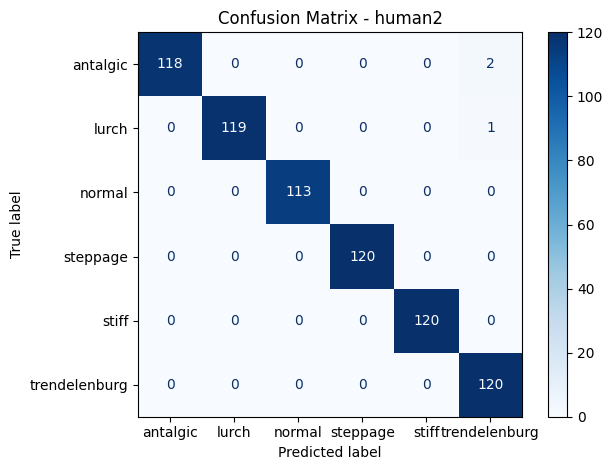

測試集準確率: 99.58% | 測試集 F1-score: 0.9958

=== 測試 Subject: human3 ===
[Epoch   5] LR: 1.00e-02 | Train Loss: 0.2316 | Train Acc: 91.66%
[Epoch  10] LR: 1.00e-02 | Train Loss: 0.1572 | Train Acc: 95.05%
[Epoch  15] LR: 1.00e-02 | Train Loss: 0.1462 | Train Acc: 95.37%
[Epoch  20] LR: 1.00e-02 | Train Loss: 0.1260 | Train Acc: 95.87%
[Epoch  25] LR: 1.00e-02 | Train Loss: 0.1044 | Train Acc: 96.77%
[Epoch  30] LR: 1.00e-03 | Train Loss: 0.1024 | Train Acc: 97.00%
[Epoch  35] LR: 1.00e-03 | Train Loss: 0.0379 | Train Acc: 99.01%
[Epoch  40] LR: 1.00e-03 | Train Loss: 0.0332 | Train Acc: 99.18%
[Epoch  45] LR: 1.00e-03 | Train Loss: 0.0352 | Train Acc: 99.16%
[Epoch  50] LR: 1.00e-03 | Train Loss: 0.0346 | Train Acc: 99.02%
[Epoch  55] LR: 1.00e-03 | Train Loss: 0.0348 | Train Acc: 99.18%
[Epoch  60] LR: 1.00e-04 | Train Loss: 0.0345 | Train Acc: 99.24%
[Epoch  65] LR: 1.00e-04 | Train Loss: 0.0211 | Train Acc: 99.63%
[Epoch  70] LR: 1.00e-04 | Train Loss: 0.0195 | Train Acc: 99.70%
[Epoch  75

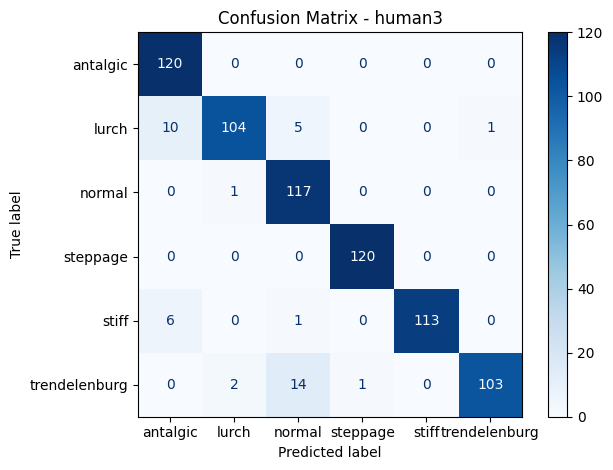

測試集準確率: 94.29% | 測試集 F1-score: 0.9428

=== 測試 Subject: human4 ===
[Epoch   5] LR: 1.00e-02 | Train Loss: 0.2083 | Train Acc: 93.43%
[Epoch  10] LR: 1.00e-02 | Train Loss: 0.1412 | Train Acc: 96.18%
[Epoch  15] LR: 1.00e-02 | Train Loss: 0.0909 | Train Acc: 97.22%
[Epoch  20] LR: 1.00e-02 | Train Loss: 0.0822 | Train Acc: 97.93%
[Epoch  25] LR: 1.00e-02 | Train Loss: 0.0884 | Train Acc: 97.56%
[Epoch  30] LR: 1.00e-03 | Train Loss: 0.0792 | Train Acc: 97.59%
[Epoch  35] LR: 1.00e-03 | Train Loss: 0.0263 | Train Acc: 99.51%
[Epoch  40] LR: 1.00e-03 | Train Loss: 0.0245 | Train Acc: 99.55%
[Epoch  45] LR: 1.00e-03 | Train Loss: 0.0265 | Train Acc: 99.49%
[Epoch  50] LR: 1.00e-03 | Train Loss: 0.0196 | Train Acc: 99.63%
[Epoch  55] LR: 1.00e-03 | Train Loss: 0.0225 | Train Acc: 99.54%
[Epoch  60] LR: 1.00e-04 | Train Loss: 0.0220 | Train Acc: 99.68%
[Epoch  65] LR: 1.00e-04 | Train Loss: 0.0158 | Train Acc: 99.74%
[Epoch  70] LR: 1.00e-04 | Train Loss: 0.0167 | Train Acc: 99.74%
[Epoch  75

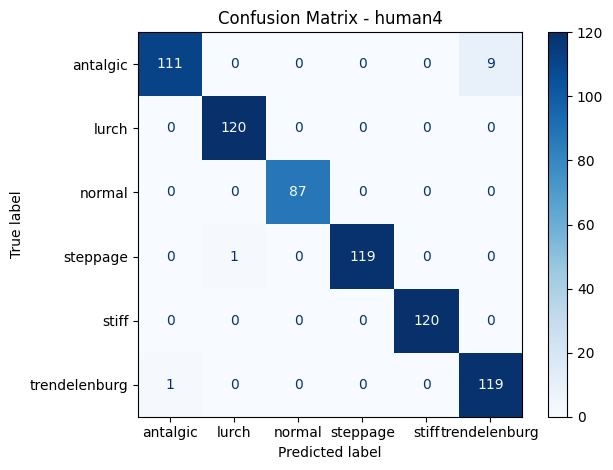

測試集準確率: 98.40% | 測試集 F1-score: 0.9847

=== 測試 Subject: human5 ===
[Epoch   5] LR: 1.00e-02 | Train Loss: 0.2040 | Train Acc: 93.52%
[Epoch  10] LR: 1.00e-02 | Train Loss: 0.1212 | Train Acc: 96.33%
[Epoch  15] LR: 1.00e-02 | Train Loss: 0.0959 | Train Acc: 97.14%
[Epoch  20] LR: 1.00e-02 | Train Loss: 0.0974 | Train Acc: 97.28%
[Epoch  25] LR: 1.00e-02 | Train Loss: 0.1057 | Train Acc: 97.05%
[Epoch  30] LR: 1.00e-03 | Train Loss: 0.0852 | Train Acc: 97.72%
[Epoch  35] LR: 1.00e-03 | Train Loss: 0.0294 | Train Acc: 99.33%
[Epoch  40] LR: 1.00e-03 | Train Loss: 0.0251 | Train Acc: 99.49%
[Epoch  45] LR: 1.00e-03 | Train Loss: 0.0263 | Train Acc: 99.47%
[Epoch  50] LR: 1.00e-03 | Train Loss: 0.0284 | Train Acc: 99.38%
[Epoch  55] LR: 1.00e-03 | Train Loss: 0.0299 | Train Acc: 99.29%
[Epoch  60] LR: 1.00e-04 | Train Loss: 0.0224 | Train Acc: 99.64%
[Epoch  65] LR: 1.00e-04 | Train Loss: 0.0151 | Train Acc: 99.78%
[Epoch  70] LR: 1.00e-04 | Train Loss: 0.0138 | Train Acc: 99.88%
[Epoch  75

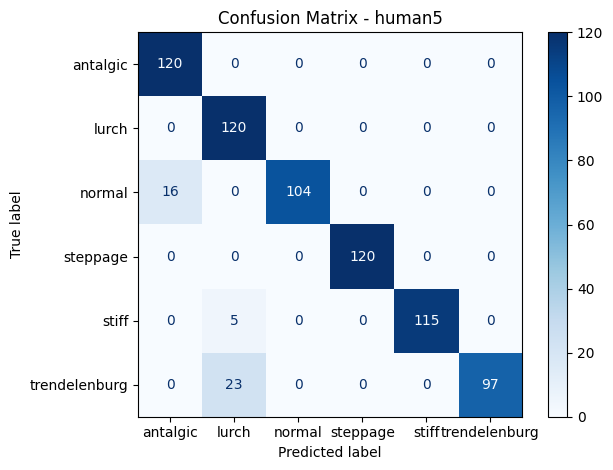

測試集準確率: 93.89% | 測試集 F1-score: 0.9391

=== 測試 Subject: human6 ===
[Epoch   5] LR: 1.00e-02 | Train Loss: 0.2366 | Train Acc: 92.06%
[Epoch  10] LR: 1.00e-02 | Train Loss: 0.1503 | Train Acc: 95.46%
[Epoch  15] LR: 1.00e-02 | Train Loss: 0.1242 | Train Acc: 96.47%
[Epoch  20] LR: 1.00e-02 | Train Loss: 0.1206 | Train Acc: 96.46%
[Epoch  25] LR: 1.00e-02 | Train Loss: 0.1118 | Train Acc: 96.77%
[Epoch  30] LR: 1.00e-03 | Train Loss: 0.1079 | Train Acc: 96.68%
[Epoch  35] LR: 1.00e-03 | Train Loss: 0.0356 | Train Acc: 99.21%
[Epoch  40] LR: 1.00e-03 | Train Loss: 0.0297 | Train Acc: 99.38%
[Epoch  45] LR: 1.00e-03 | Train Loss: 0.0308 | Train Acc: 99.33%
[Epoch  50] LR: 1.00e-03 | Train Loss: 0.0288 | Train Acc: 99.49%
[Epoch  55] LR: 1.00e-03 | Train Loss: 0.0313 | Train Acc: 99.49%
[Epoch  60] LR: 1.00e-04 | Train Loss: 0.0248 | Train Acc: 99.53%
[Epoch  65] LR: 1.00e-04 | Train Loss: 0.0185 | Train Acc: 99.77%
[Epoch  70] LR: 1.00e-04 | Train Loss: 0.0187 | Train Acc: 99.67%
[Epoch  75

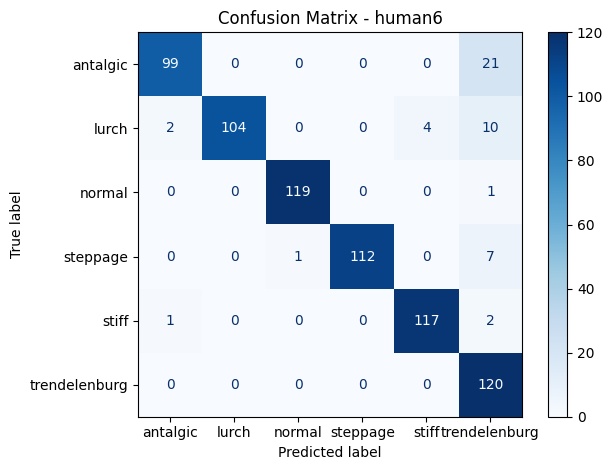

測試集準確率: 93.19% | 測試集 F1-score: 0.9338

=== 測試 Subject: human7 ===
[Epoch   5] LR: 1.00e-02 | Train Loss: 0.1844 | Train Acc: 94.11%
[Epoch  10] LR: 1.00e-02 | Train Loss: 0.1367 | Train Acc: 95.56%
[Epoch  15] LR: 1.00e-02 | Train Loss: 0.1115 | Train Acc: 96.69%
[Epoch  20] LR: 1.00e-02 | Train Loss: 0.1100 | Train Acc: 96.60%
[Epoch  25] LR: 1.00e-02 | Train Loss: 0.1029 | Train Acc: 96.85%
[Epoch  30] LR: 1.00e-03 | Train Loss: 0.0953 | Train Acc: 97.06%
[Epoch  35] LR: 1.00e-03 | Train Loss: 0.0336 | Train Acc: 99.15%
[Epoch  40] LR: 1.00e-03 | Train Loss: 0.0295 | Train Acc: 99.33%
[Epoch  45] LR: 1.00e-03 | Train Loss: 0.0316 | Train Acc: 99.24%
[Epoch  50] LR: 1.00e-03 | Train Loss: 0.0235 | Train Acc: 99.49%
[Epoch  55] LR: 1.00e-03 | Train Loss: 0.0340 | Train Acc: 99.22%
[Epoch  60] LR: 1.00e-04 | Train Loss: 0.0226 | Train Acc: 99.64%
[Epoch  65] LR: 1.00e-04 | Train Loss: 0.0170 | Train Acc: 99.78%
[Epoch  70] LR: 1.00e-04 | Train Loss: 0.0165 | Train Acc: 99.78%
[Epoch  75

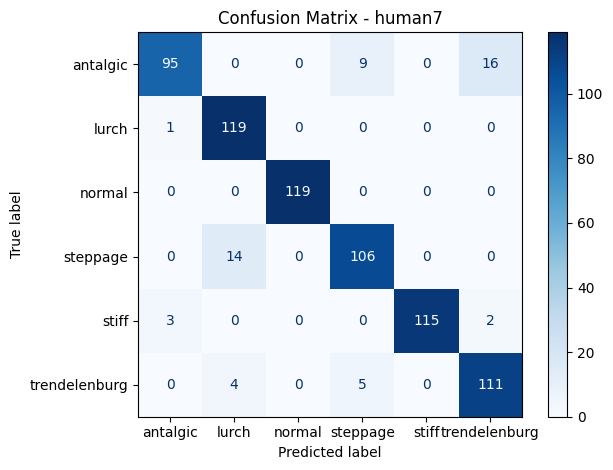

測試集準確率: 92.49% | 測試集 F1-score: 0.9245

=== 測試 Subject: human8 ===
[Epoch   5] LR: 1.00e-02 | Train Loss: 0.2099 | Train Acc: 93.41%
[Epoch  10] LR: 1.00e-02 | Train Loss: 0.1196 | Train Acc: 96.38%
[Epoch  15] LR: 1.00e-02 | Train Loss: 0.1044 | Train Acc: 96.82%
[Epoch  20] LR: 1.00e-02 | Train Loss: 0.0772 | Train Acc: 97.81%
[Epoch  25] LR: 1.00e-02 | Train Loss: 0.0701 | Train Acc: 98.07%
[Epoch  30] LR: 1.00e-03 | Train Loss: 0.0859 | Train Acc: 97.36%
[Epoch  35] LR: 1.00e-03 | Train Loss: 0.0357 | Train Acc: 99.27%
[Epoch  40] LR: 1.00e-03 | Train Loss: 0.0301 | Train Acc: 99.36%
[Epoch  45] LR: 1.00e-03 | Train Loss: 0.0331 | Train Acc: 99.24%
[Epoch  50] LR: 1.00e-03 | Train Loss: 0.0238 | Train Acc: 99.64%
[Epoch  55] LR: 1.00e-03 | Train Loss: 0.0292 | Train Acc: 99.33%
[Epoch  60] LR: 1.00e-04 | Train Loss: 0.0280 | Train Acc: 99.44%
[Epoch  65] LR: 1.00e-04 | Train Loss: 0.0201 | Train Acc: 99.64%
[Epoch  70] LR: 1.00e-04 | Train Loss: 0.0174 | Train Acc: 99.75%
[Epoch  75

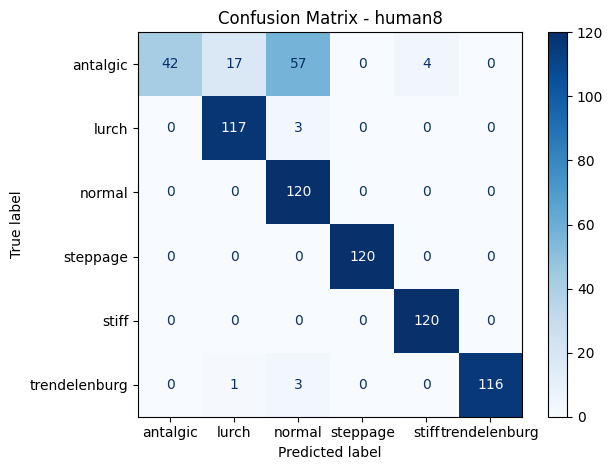

測試集準確率: 88.19% | 測試集 F1-score: 0.8658

=== 測試 Subject: human9 ===
[Epoch   5] LR: 1.00e-02 | Train Loss: 0.1956 | Train Acc: 93.72%
[Epoch  10] LR: 1.00e-02 | Train Loss: 0.1196 | Train Acc: 96.27%
[Epoch  15] LR: 1.00e-02 | Train Loss: 0.1175 | Train Acc: 96.26%
[Epoch  20] LR: 1.00e-02 | Train Loss: 0.1223 | Train Acc: 96.19%
[Epoch  25] LR: 1.00e-02 | Train Loss: 0.1123 | Train Acc: 96.43%
[Epoch  30] LR: 1.00e-03 | Train Loss: 0.0857 | Train Acc: 97.72%
[Epoch  35] LR: 1.00e-03 | Train Loss: 0.0368 | Train Acc: 99.15%
[Epoch  40] LR: 1.00e-03 | Train Loss: 0.0396 | Train Acc: 99.01%
[Epoch  45] LR: 1.00e-03 | Train Loss: 0.0324 | Train Acc: 99.29%
[Epoch  50] LR: 1.00e-03 | Train Loss: 0.0319 | Train Acc: 99.38%
[Epoch  55] LR: 1.00e-03 | Train Loss: 0.0310 | Train Acc: 99.39%
[Epoch  60] LR: 1.00e-04 | Train Loss: 0.0307 | Train Acc: 99.29%
[Epoch  65] LR: 1.00e-04 | Train Loss: 0.0191 | Train Acc: 99.64%
[Epoch  70] LR: 1.00e-04 | Train Loss: 0.0172 | Train Acc: 99.74%
[Epoch  75

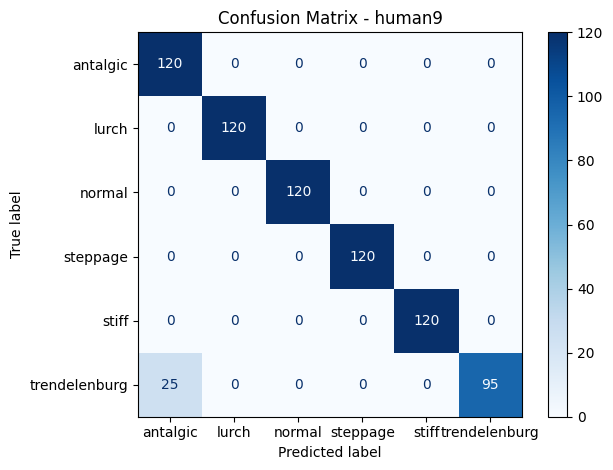

測試集準確率: 96.53% | 測試集 F1-score: 0.9649

=== LOSO 總結 ===
human1: Acc=100.00% | F1=1.0000
human10: Acc=97.64% | F1=0.9764
human2: Acc=99.58% | F1=0.9958
human3: Acc=94.29% | F1=0.9428
human4: Acc=98.40% | F1=0.9847
human5: Acc=93.89% | F1=0.9391
human6: Acc=93.19% | F1=0.9338
human7: Acc=92.49% | F1=0.9245
human8: Acc=88.19% | F1=0.8658
human9: Acc=96.53% | F1=0.9649

平均準確率: 95.42%
最大準確率: 100.00%
最小準確率: 88.19%
標準差: 3.50%

平均 F1-score: 0.9528
[Saved] Per-fold test metrics → logs\fold_test_metrics.csv
[Saved] Summary metrics → logs\summary_metrics.csv
[Saved] Summary metrics → logs\summary_metrics.json
[Saved] LOSO 結果文字檔 → logs\loso_summary.txt


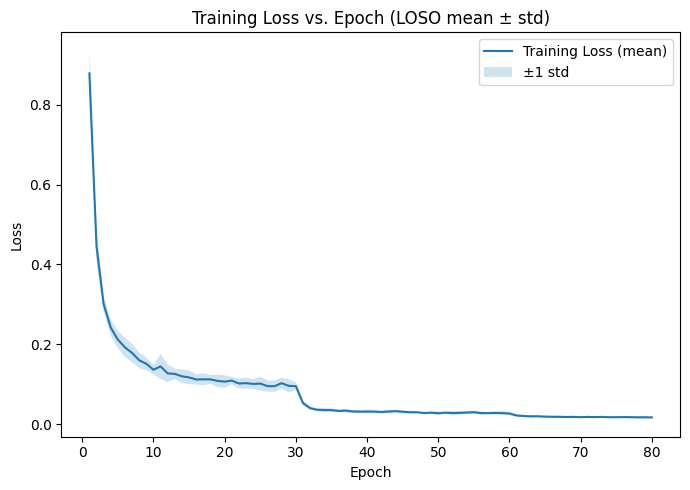

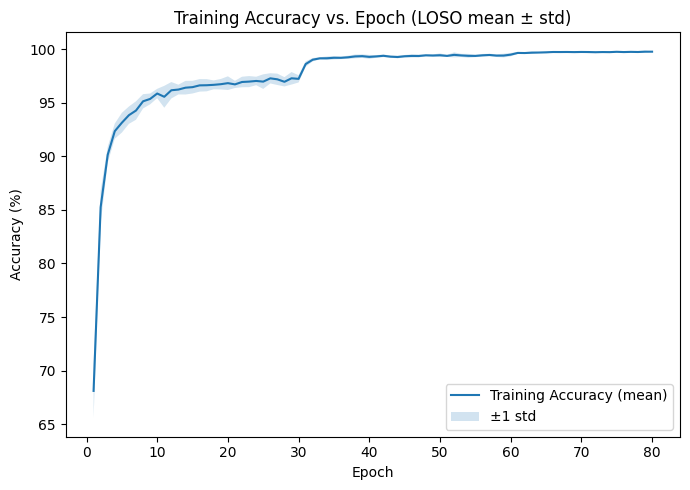

已輸出：
 - 每個 fold 的曲線 CSV：logs/train_curve_<subject>.csv
 - 彙整曲線 CSV：logs/train_curves_loso_mean_std.csv
 - 圖檔：logs/train_loss_loso_mean_std.png / logs/train_acc_loso_mean_std.png


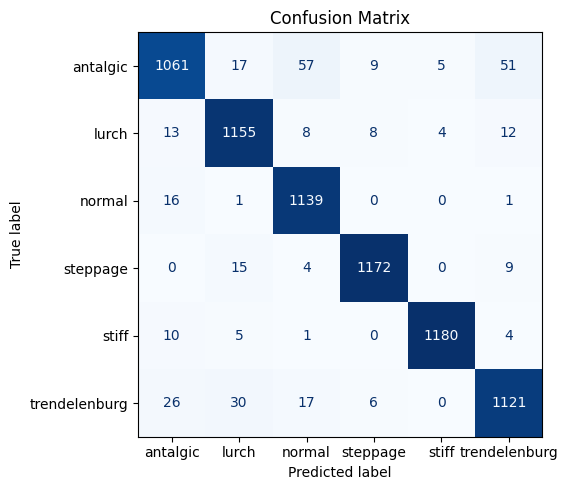

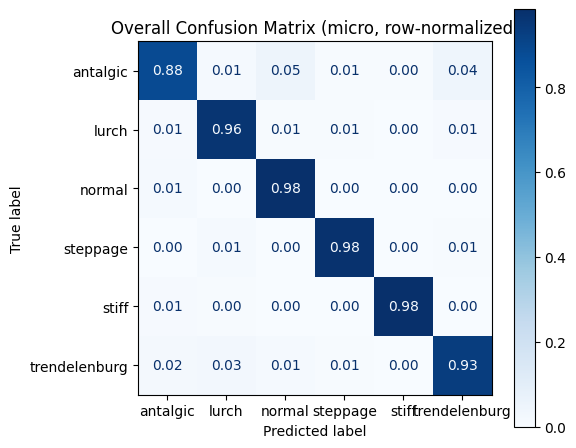

[Saved] CM (counts) → logs\overall_cm_micro_counts.csv
[Saved] CM (row-normalized) → logs\overall_cm_micro_rowNorm.csv


In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from net.mt_gsgcn_model import Model  # 你的模型

# ===================== 可調參數 =====================
DATA_PATH = "../datasets/processed_data/patho50_data_noNorm.npz"
TOTAL_EPOCHS = 80
BATCH_SIZE = 32
LR = 0.01
WEIGHT_DECAY = 0.001
PRINT_MODE = "fixed"   # "fixed" 或 "adaptive"
PRINT_EVERY = 5        # PRINT_MODE="fixed" 時，每幾個 epoch 列印一次
SHOW_FOLD_CM = True    # 是否顯示每個 fold 的混淆矩陣圖（會比較慢）
LOG_DIR = "logs"
os.makedirs(LOG_DIR, exist_ok=True)

# 類別名稱（需與 label 編碼一致）
CLASS_NAMES = ['antalgic','lurch','normal','steppage','stiff','trendelenburg']
NUM_CLASSES = len(CLASS_NAMES)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===================== 載入資料 =====================
npz = np.load(DATA_PATH)
data = npz["data"]         # (N, 3, 50, 7, 1)
labels = npz["labels"]     # (N,)
subjects = npz["subjects"] # (N,)
unique_subjects = np.unique(subjects)

# ===================== 建立模型 =====================
def build_ags_gcn():
    return Model(in_channels=3, num_class=NUM_CLASSES,
                 graph_args={'layout': 'custom_7joints_spine', 'strategy': 'spatial'},
                 edge_importance_weighting=True)

# ===================== 訓練（回傳逐 epoch 的 loss/acc） =====================
def train_model(model, train_loader, total_epochs=80,
                lr=0.01, weight_decay=1e-3,
                print_mode="fixed", print_every=5):
    """
    回傳: (epoch_losses, epoch_accs) 兩個 list，長度 = total_epochs
    """
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)
    criterion = nn.CrossEntropyLoss()

    epoch_losses, epoch_accs = [], []

    def should_print(ep_idx):
        e = ep_idx + 1  # 1-based
        if print_mode == "adaptive":
            if e <= 10:                return True
            if e <= 200 and e % 25==0: return True
            return (e % 50 == 0)
        else:
            return (e % max(1, print_every) == 0)

    for epoch in range(total_epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            out = model(X_batch.to(device))
            loss = criterion(out, y_batch.to(device))
            loss.backward()
            # 如需更穩定可開啟梯度裁剪（會稍慢）
            # torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item() * y_batch.size(0)
            preds = out.argmax(dim=1)
            correct += (preds.cpu() == y_batch).sum().item()
            total += y_batch.size(0)

        scheduler.step()

        avg_loss = total_loss / max(total, 1)
        acc = correct / max(total, 1) * 100.0
        epoch_losses.append(avg_loss)
        epoch_accs.append(acc)

        if should_print(epoch):
            cur_lr = optimizer.param_groups[0]['lr']
            print(f"[Epoch {epoch+1:>3d}] LR: {cur_lr:.2e} | Train Loss: {avg_loss:.4f} | Train Acc: {acc:.2f}%")

    return epoch_losses, epoch_accs

# ===================== 測試（回傳 preds/trues 與該 fold 的 cm） =====================
def evaluate_model(model, test_loader, subject_name, show_cm=False):
    model.eval()
    preds_all, trues_all = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            logits = model(X_batch.to(device))
            preds = logits.argmax(dim=1).cpu().numpy()
            preds_all.extend(preds)
            trues_all.extend(y_batch.numpy())

    acc = np.mean(np.array(preds_all) == np.array(trues_all)) * 100.0
    f1 = f1_score(trues_all, preds_all, average='macro')

    cm_fold = confusion_matrix(trues_all, preds_all, labels=list(range(NUM_CLASSES)))
    if show_cm:
        disp = ConfusionMatrixDisplay(cm_fold, display_labels=CLASS_NAMES)
        disp.plot(cmap='Blues')
        plt.title(f"Confusion Matrix - {subject_name}")
        plt.tight_layout()
        # 需要也可存每 fold 的圖
        plt.savefig(os.path.join(LOG_DIR, f"cm_{subject_name}.png"), dpi=300)
        plt.show()

    return acc, f1, preds_all, trues_all, cm_fold

# ===================== LOSO 實驗（Leave-One-Subject-Out，逐一受試者留一法） =====================
results = []
all_preds, all_trues = [], []  # 用於「總體（micro）」混淆矩陣
global_cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)  # 直接累加各 fold 的計數
loss_curves, acc_curves = [], []  # 收集每個 fold 的訓練曲線

for i, test_sub in enumerate(unique_subjects):
    print(f"\n=== 測試 Subject: {test_sub} ===")

    test_idx = (subjects == test_sub)
    train_idx = ~test_idx

    X_train = torch.tensor(data[train_idx], dtype=torch.float32)  # (N, 3, 50, 7, 1)
    y_train = torch.tensor(labels[train_idx], dtype=torch.long)
    X_test  = torch.tensor(data[test_idx], dtype=torch.float32)
    y_test  = torch.tensor(labels[test_idx], dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_train, y_train),
                              batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=4, pin_memory=True, persistent_workers=True)
    test_loader  = DataLoader(TensorDataset(X_test,  y_test),
                              batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=4, pin_memory=True, persistent_workers=True)

    model = build_ags_gcn()
    # 訓練，並取回逐 epoch 曲線
    losses, accs = train_model(model, train_loader, total_epochs=TOTAL_EPOCHS,
                               lr=LR, weight_decay=WEIGHT_DECAY,
                               print_mode=PRINT_MODE, print_every=PRINT_EVERY)

    # 存每個 fold 的訓練曲線 CSV
    sub_name = str(test_sub)
    pd.DataFrame({
        "epoch": np.arange(1, TOTAL_EPOCHS + 1),
        "train_loss": losses,
        "train_acc(%)": accs
    }).to_csv(os.path.join(LOG_DIR, f"train_curve_{sub_name}.csv"), index=False)

    loss_curves.append(losses)
    acc_curves.append(accs)

    # 測試並（選擇性）顯示該 fold 混淆矩陣
    acc, f1, preds_fold, trues_fold, cm_fold = evaluate_model(model, test_loader, sub_name, show_cm=SHOW_FOLD_CM)
    results.append((sub_name, acc, f1))
    print(f"測試集準確率: {acc:.2f}% | 測試集 F1-score: {f1:.4f}")

    # micro 用：收集所有測試結果，或直接累加 cm（兩者等價）
    all_preds.extend(preds_fold)
    all_trues.extend(trues_fold)
    global_cm += cm_fold

# ===================== 總結（各 fold 指標） =====================
acc_list = [r[1] for r in results]
f1_list  = [r[2] for r in results]
print("\n=== LOSO 總結 ===")
for sub, acc, f1 in results:
    print(f"{sub}: Acc={acc:.2f}% | F1={f1:.4f}")
print(f"\n平均準確率: {np.mean(acc_list):.2f}%")
print(f"最大準確率: {np.max(acc_list):.2f}%")
print(f"最小準確率: {np.min(acc_list):.2f}%")
print(f"標準差: {np.std(acc_list):.2f}%")
print(f"\n平均 F1-score: {np.mean(f1_list):.4f}")

# ===================== 存每個 fold 與整體摘要（CSV/JSON/TXT） =====================
# 每個 fold 的測試指標
fold_metrics_df = pd.DataFrame(results, columns=["subject", "acc_percent", "f1_macro"])
fold_metrics_path = os.path.join(LOG_DIR, "fold_test_metrics.csv")
fold_metrics_df.to_csv(fold_metrics_path, index=False)
print(f"[Saved] Per-fold test metrics → {fold_metrics_path}")

# micro overall（用整體混淆矩陣）
micro_overall_acc = float((global_cm.trace() / global_cm.sum()) * 100.0) if global_cm.sum() > 0 else 0.0

# 整體摘要（單列）
summary = {
    "num_subjects": int(len(unique_subjects)),
    "num_classes": int(NUM_CLASSES),
    "total_test_samples": int(global_cm.sum()),
    "macro_acc_mean_percent": float(np.mean(acc_list)),
    "macro_acc_std_percent":  float(np.std(acc_list)),
    "macro_acc_min_percent":  float(np.min(acc_list)),
    "macro_acc_max_percent":  float(np.max(acc_list)),
    "macro_f1_mean":          float(np.mean(f1_list)),
    "micro_overall_acc_percent": micro_overall_acc,
    # 超參數記錄
    "EPOCHS": int(TOTAL_EPOCHS),
    "BATCH_SIZE": int(BATCH_SIZE),
    "LR": float(LR),
    "WEIGHT_DECAY": float(WEIGHT_DECAY),
    "DATA_PATH": DATA_PATH,
}
summary_csv_path  = os.path.join(LOG_DIR, "summary_metrics.csv")
summary_json_path = os.path.join(LOG_DIR, "summary_metrics.json")
pd.Series(summary).to_csv(summary_csv_path, header=False)
with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
print(f"[Saved] Summary metrics → {summary_csv_path}")
print(f"[Saved] Summary metrics → {summary_json_path}")

# 輸出 LOSO 結果文字檔
summary_txt_path = os.path.join(LOG_DIR, "loso_summary.txt")
with open(summary_txt_path, "w", encoding="utf-8") as f:
    f.write("=== LOSO 總結 ===\n")
    for sub, acc, f1 in results:
        f.write(f"{sub}: Acc={acc:.2f}% | F1={f1:.4f}\n")
    f.write("\n")
    f.write(f"平均準確率: {np.mean(acc_list):.2f}%\n")
    f.write(f"最大準確率: {np.max(acc_list):.2f}%\n")
    f.write(f"最小準確率: {np.min(acc_list):.2f}%\n")
    f.write(f"標準差: {np.std(acc_list):.2f}%\n")
    f.write(f"\n平均 F1-score: {np.mean(f1_list):.4f}\n")
    f.write(f"Micro overall Acc: {micro_overall_acc:.2f}%\n")
    f.write("\n[Hyperparams]\n")
    f.write(f"EPOCHS={TOTAL_EPOCHS}, BATCH_SIZE={BATCH_SIZE}, LR={LR}, WEIGHT_DECAY={WEIGHT_DECAY}\n")
    f.write(f"DATA_PATH={DATA_PATH}\n")
print(f"[Saved] LOSO 結果文字檔 → {summary_txt_path}")

# ===================== 訓練曲線 LOSO 平均 ± 標準差 =====================
loss_curves = np.array(loss_curves)  # (folds, epochs)
acc_curves  = np.array(acc_curves)   # (folds, epochs)
epochs = np.arange(1, TOTAL_EPOCHS + 1)

mean_loss = loss_curves.mean(axis=0)
std_loss  = loss_curves.std(axis=0)
mean_acc  = acc_curves.mean(axis=0)
std_acc   = acc_curves.std(axis=0)

# 存彙整 CSV（論文製圖方便）
pd.DataFrame({
    "epoch": epochs,
    "train_loss_mean": mean_loss,
    "train_loss_std": std_loss,
    "train_acc_mean(%)": mean_acc,
    "train_acc_std(%)": std_acc
}).to_csv(os.path.join(LOG_DIR, "train_curves_loso_mean_std.csv"), index=False)

# 畫訓練 Loss 曲線
plt.figure(figsize=(7,5))
plt.plot(epochs, mean_loss, label="Training Loss (mean)")
plt.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, alpha=0.2, label="±1 std")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training Loss vs. Epoch (LOSO mean ± std)")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "train_loss_loso_mean_std.png"), dpi=300)
plt.show()

# 畫訓練 Accuracy 曲線
plt.figure(figsize=(7,5))
plt.plot(epochs, mean_acc, label="Training Accuracy (mean)")
plt.fill_between(epochs, mean_acc - std_acc, mean_acc + std_acc, alpha=0.2, label="±1 std")
plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy vs. Epoch (LOSO mean ± std)")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "train_acc_loso_mean_std.png"), dpi=300)
plt.show()

print("已輸出：")
print(f" - 每個 fold 的曲線 CSV：{LOG_DIR}/train_curve_<subject>.csv")
print(f" - 彙整曲線 CSV：{LOG_DIR}/train_curves_loso_mean_std.csv")
print(f" - 圖檔：{LOG_DIR}/train_loss_loso_mean_std.png / {LOG_DIR}/train_acc_loso_mean_std.png")

# ===================== 產生「整體（micro）混淆矩陣」 =====================
micro_cm_from_pairs = confusion_matrix(all_trues, all_preds, labels=list(range(NUM_CLASSES)))
assert (micro_cm_from_pairs == global_cm).all(), "micro_cm 與 global_cm 不一致，請確認 label 對應"

# counts 版
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(global_cm, display_labels=CLASS_NAMES).plot(
    cmap='Blues', ax=ax, values_format='d', colorbar=False
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "overall_cm_micro_counts.png"), dpi=300)
plt.show()

# row-normalized 版（每列百分比）
row_sums = global_cm.sum(axis=1, keepdims=True).clip(min=1)
global_cm_row = global_cm / row_sums
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(global_cm_row, display_labels=CLASS_NAMES).plot(
    cmap='Blues', ax=ax, values_format='.2f', colorbar=True
)
plt.title("Overall Confusion Matrix (micro, row-normalized)")
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "overall_cm_micro_rowNorm.png"), dpi=300)
plt.show()

# 也把 CM 存成 CSV（方便 Excel / LaTeX）
cm_counts_path = os.path.join(LOG_DIR, "overall_cm_micro_counts.csv")
cm_rowNorm_path = os.path.join(LOG_DIR, "overall_cm_micro_rowNorm.csv")
pd.DataFrame(global_cm, columns=CLASS_NAMES, index=CLASS_NAMES).to_csv(cm_counts_path)
pd.DataFrame(global_cm_row, columns=CLASS_NAMES, index=CLASS_NAMES).to_csv(cm_rowNorm_path)
print(f"[Saved] CM (counts) → {cm_counts_path}")
print(f"[Saved] CM (row-normalized) → {cm_rowNorm_path}")


In [2]:
import torch
from thop import profile, clever_format

from net.mt_gsgcn_cbam_model import Model  # ← 換成你的實際模型檔案

def model_stats():
    # 1) 建立模型（確認與另一个模型完全相同的設定）
    model = Model(
        in_channels=3,
        num_class=3,
        graph_args={'layout': 'custom_7joints_spine', 'strategy': 'spatial'},
        edge_importance_weighting=True,
        # use_cbam=False  # ← 第1個方法關掉；第2個方法打開
    ).eval().cpu()

    # 2) 固定輸入規格 (N, C, T, V, M) = (1, 3, 48, 7, 1)
    x = torch.randn(1, 3, 50, 7, 1)

    # 3) 用 thop 統計
    with torch.no_grad():
        macs, params = profile(model, inputs=(x,), verbose=False)  # macs=乘加(MACs)

    # 4) 轉成可讀格式
    # thop 的 macs 是「乘加數」；若你採用「1 MAC = 2 FLOPs」慣例，請乘 2
    flops = macs * 2
    flops_str, params_str = clever_format([flops, params], "%.2f")

    print("========== 模型統計 ==========")
    print(f"Total parameters : {params:,}  ({params_str})")
    print(f"FLOPs (1 MAC=2 FLOPs) : {flops:,}  ({flops_str})")
    print("================================")

if __name__ == "__main__":
    model_stats()


========== 模型統計 ==========
Total parameters : 4,803,699.0  (4.80M)
FLOPs (1 MAC=2 FLOPs) : 1,980,390,128.0  (1.98G)


In [63]:
import time
import numpy as np
import torch

from net.mt_gsgcn_model import Model

# =========================
# 1. Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# 2. 建立模型（⚠️ 必須和訓練時一樣）
# =========================
model = Model(
    in_channels=3,
    num_class=6,   # Patho50 / GIST 是 6 類
    graph_args={'layout': 'custom_7joints_spine', 'strategy': 'spatial'},
    edge_importance_weighting=True
)

model = model.to(device)

# =========================
# 3. 載入訓練好的權重
# =========================
ckpt_path = "models/mt_gsgcn_subject_human1_ckpt.pt"
ckpt = torch.load(ckpt_path, map_location=device)

if isinstance(ckpt, dict):
    if "state_dict" in ckpt:
        state_dict = ckpt["state_dict"]
    elif "model_state_dict" in ckpt:
        state_dict = ckpt["model_state_dict"]
    else:
        state_dict = ckpt
else:
    raise RuntimeError("Checkpoint format error")

# 移除 DataParallel 的 module.（如果有）
state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

model.load_state_dict(state_dict, strict=False)
model.eval()

print("Model loaded and set to eval().")

# =========================
# 4. 載入一筆資料（單筆）
# =========================
sample_path = "../datasets/demo_samples/antalgic/human1_antalgic_05.npy"
x_np = np.load(sample_path)              # (3, 50, 7, 1)

x_single = torch.from_numpy(x_np).float()
x_single = x_single.unsqueeze(0)          # (1, 3, 50, 7, 1)
x_single = x_single.to(device)

print("Input shape:", x_single.shape)

# =========================
# 5. 推論時間量測（重點）
# =========================
times = []

with torch.no_grad():
    # warm-up（GPU 一定要）
    for _ in range(10):
        _ = model(x_single)

    # 正式量測
    for _ in range(100):
        if x_single.is_cuda:
            torch.cuda.synchronize()
        start = time.time()

        _ = model(x_single)

        if x_single.is_cuda:
            torch.cuda.synchronize()
        end = time.time()

        times.append((end - start) * 1000)  # ms

avg_ms = np.mean(times)
std_ms = np.std(times)

print("===================================")
print(f"Average inference time: {avg_ms:.3f} ms")
print(f"Std: {std_ms:.3f} ms")
print(f"= {avg_ms/1000:.6f} seconds per sample")
print("===================================")


Using device: cuda
Model loaded and set to eval().
Input shape: torch.Size([1, 3, 50, 7, 1])
Average inference time: 2.988 ms
Std: 0.595 ms
= 0.002988 seconds per sample


In [57]:
import time
import numpy as np
import torch

from net.mt_gsgcn_cbam_model import Model

# =========================
# 1. Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# 2. 建立模型（⚠️ 必須和訓練時一樣）
# =========================
model = Model(
    in_channels=3,
    num_class=6,   # Patho50 / GIST 是 6 類
    graph_args={'layout': 'custom_7joints_spine', 'strategy': 'spatial'},
    edge_importance_weighting=True
)

model = model.to(device)

# =========================
# 3. 載入訓練好的權重
# =========================
ckpt_path = "models/mt_gsgcn_subject_human1_ckpt.pt"
ckpt = torch.load(ckpt_path, map_location=device)

if isinstance(ckpt, dict):
    if "state_dict" in ckpt:
        state_dict = ckpt["state_dict"]
    elif "model_state_dict" in ckpt:
        state_dict = ckpt["model_state_dict"]
    else:
        state_dict = ckpt
else:
    raise RuntimeError("Checkpoint format error")

# 移除 DataParallel 的 module.（如果有）
state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

model.load_state_dict(state_dict, strict=False)
model.eval()

print("Model loaded and set to eval().")

# =========================
# 4. 載入一筆資料（單筆）
# =========================
sample_path = "../datasets/demo_samples/antalgic/human1_antalgic_05.npy"
x_np = np.load(sample_path)              # (3, 50, 7, 1)

x_single = torch.from_numpy(x_np).float()
x_single = x_single.unsqueeze(0)          # (1, 3, 50, 7, 1)
x_single = x_single.to(device)

print("Input shape:", x_single.shape)

# =========================
# 5. 推論時間量測（重點）
# =========================
times = []

with torch.no_grad():
    # warm-up（GPU 一定要）
    for _ in range(10):
        _ = model(x_single)

    # 正式量測
    for _ in range(100):
        if x_single.is_cuda:
            torch.cuda.synchronize()
        start = time.time()

        _ = model(x_single)

        if x_single.is_cuda:
            torch.cuda.synchronize()
        end = time.time()

        times.append((end - start) * 1000)  # ms

avg_ms = np.mean(times)
std_ms = np.std(times)

print("===================================")
print(f"Average inference time: {avg_ms:.3f} ms")
print(f"Std: {std_ms:.3f} ms")
print(f"= {avg_ms/1000:.6f} seconds per sample")
print("===================================")


Using device: cuda
Model loaded and set to eval().
Input shape: torch.Size([1, 3, 50, 7, 1])
Average inference time: 3.569 ms
Std: 0.602 ms
= 0.003569 seconds per sample
